
## Fraud Detection in Financial Transactions

---

---

## Section 1: Introduction & Architecture Blueprint

### 1.1 Project Overview

This project demonstrates a complete pipeline that integrates multiple heterogeneous 
financial transaction datasets into a unified **SQLite Data Warehouse** using a **Star Schema** design. 
We then apply **Data Mining** techniques and **Machine Learning** to detect fraudulent transactions.

### 1.2 The Four Source Datasets

| Dataset | Description | Key Columns | Records |
|---------|-------------|-------------|---------|
| **Custom Fraud** | Synthetic fraud dataset with rich features | Transaction_ID, User_ID, Amount, Risk_Score, Fraud_Label | 50,000 |
| **PaySim** | Mobile money transaction simulation | step, type, amount, nameOrig, nameDest, isFraud | 6,362,620 |
| **BankSim** | Bank transactions with demographics | customer, age, gender, merchant, category, fraud | 594,643 |
| **BankSim Network** | Graph representation of transactions | Source, Target, Weight, typeTrans, fraud | 594,643 |

### 1.3 Star Schema Architecture

The **Star Schema** is the industry-standard architecture for data warehouses because:

1. **Query Performance**: Denormalized structure enables fast analytical queries
2. **Simplicity**: Easy to understand with a central Fact table surrounded by Dimensions
3. **Flexibility**: Dimension tables can evolve independently
4. **BI Tool Compatibility**: Works seamlessly with visualization and reporting tools

```
                         ┌─────────────┐
                         │  DimUser    │
                         │─────────────│
                         │ user_key(PK)│
                         │ user_id     │
                         │ age_group   │
                         │ gender      │
                         │ zip_code    │
                         └──────┬──────┘
                                │
    ┌─────────────┐      ┌──────┴──────┐      ┌─────────────┐
    │ DimMerchant │      │    FACT     │      │  DimTime    │
    │─────────────│      │TRANSACTIONS │      │─────────────│
    │merchant_key │◄─────│─────────────│─────►│ time_key(PK)│
    │ (PK)        │      │ txn_key(PK) │      │ hour        │
    │ merchant_id │      │ user_key(FK)│      │ day         │
    │ zip_code    │      │merchant_key │      │ month       │
    └─────────────┘      │ (FK)        │      │ day_of_week │
                         │ time_key(FK)│      │ is_weekend  │
    ┌─────────────┐      │category_key │      └─────────────┘
    │ DimCategory │      │ (FK)        │
    │─────────────│◄─────│ amount      │
    │category_key │      │ fraud_label │
    │ (PK)        │      │ source_ds   │
    │ category    │      │ risk_score  │
    │ txn_type    │      └─────────────┘
    └─────────────┘
```

### 1.4 How Datasets Unify Under This Architecture

| Dimension | Custom Fraud | PaySim | BankSim |
|-----------|-------------|--------|---------|
| **DimUser** | User_ID | nameOrig | customer, age, gender |
| **DimMerchant** | Merchant_Category | nameDest | merchant, zipMerchant |
| **DimTime** | Timestamp | step (hourly) | step (hourly) |
| **DimCategory** | Transaction_Type | type | category |
| **FactTransactions** | Amount, Fraud_Label | amount, isFraud | amount, fraud |

This unified schema allows us to:
- **Query across all datasets** with a single SQL statement
- **Compare fraud patterns** across different data sources
- **Build unified ML models** that leverage features from all sources

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime
import warnings
import uuid
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')



# 2.2 Define Data Paths

DATA_DIR = "data/"

CUSTOM_FRAUD_PATH = DATA_DIR + "fraud/synthetic_fraud_dataset.csv"
PAYSIM_PATH = DATA_DIR + "paysim/PS_20174392719_1491204439457_log.csv"
BANKSIM_PATH = DATA_DIR + "banksim/bs140513_032310.csv"
BANKSIM_NET_PATH = DATA_DIR + "banksim/bsNET140513_032310.csv"

# SQLite database path
DB_PATH = "fraud_data_warehouse.db"

print(f"\nData sources configured:")
print(f"   - Custom Fraud: {CUSTOM_FRAUD_PATH}")
print(f"   - PaySim: {PAYSIM_PATH}")
print(f"   - BankSim: {BANKSIM_PATH}")
print(f"   - BankSim Network: {BANKSIM_NET_PATH}")
print(f"   - Data Warehouse: {DB_PATH}")

# ----------------------------------------------------------------------------
# 2.3 Create SQLite Database Connection
# ----------------------------------------------------------------------------

def create_database_connection(db_path):
    """
    Establish a connection to the SQLite database.
    Creates the database file if it doesn't exist.
    """
    conn = sqlite3.connect(db_path)
    print(f"\nConnected to SQLite database: {db_path}")
    return conn

# Create connection
conn = create_database_connection(DB_PATH)
cursor = conn.cursor()

# Enforce FK constraints (SQLite requires explicit enabling)
conn.execute("PRAGMA foreign_keys = ON")
fk_status = conn.execute("PRAGMA foreign_keys").fetchone()[0]
print(f" SQLite foreign key enforcement: {'ON' if fk_status else 'OFF'}")

# ----------------------------------------------------------------------------
# 2.3.1 ETL Audit Logging (DW requirement: lineage & reproducibility)
# ----------------------------------------------------------------------------

RUN_ID = uuid.uuid4().hex

def init_etl_audit_table(conn):
    """Create an audit table to log ETL events (counts, status, messages)."""
    conn.execute("""
        CREATE TABLE IF NOT EXISTS EtlAudit (
            audit_id INTEGER PRIMARY KEY AUTOINCREMENT,
            run_id TEXT NOT NULL,
            event_time TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            phase TEXT NOT NULL,
            dataset TEXT,
            table_name TEXT,
            rows_count INTEGER,
            status TEXT NOT NULL,
            message TEXT
        )
    """)
    conn.commit()

def log_etl_event(conn, run_id, phase, status, dataset=None, table_name=None, rows_count=None, message=None):
    conn.execute(
        """
        INSERT INTO EtlAudit (run_id, phase, dataset, table_name, rows_count, status, message)
        VALUES (?, ?, ?, ?, ?, ?, ?)
        """,
        (run_id, phase, dataset, table_name, rows_count, status, message),
    )
    conn.commit()

init_etl_audit_table(conn)
log_etl_event(conn, RUN_ID, phase="init", status="OK", message="Pipeline started")
print(f" ETL Audit enabled. run_id={RUN_ID}")

# ----------------------------------------------------------------------------
# 2.4 Create Star Schema Tables with DDL
# ----------------------------------------------------------------------------

UNKNOWN_DIM_KEY = 0

def create_star_schema(conn):
    """
    Create the Star Schema tables for our Data Warehouse.
    
    Architecture:
    - 4 Dimension Tables: DimUser, DimMerchant, DimTime, DimCategory
    - 1 Fact Table: FactTransactions
    
    Design Decisions:
    - Surrogate keys (INTEGER PRIMARY KEY) for all dimensions
    - Foreign key constraints for referential integrity
    - Source dataset tracking for lineage
    """
    cursor = conn.cursor()
    
    # Drop existing tables to start fresh (for reproducibility)
    tables = ['FactTransactions', 'DimUser', 'DimMerchant', 'DimTime', 'DimCategory']
    for table in tables:
        cursor.execute(f"DROP TABLE IF EXISTS {table}")
    
    # -------------------------------------------------------------------------
    # Dimension Table: DimUser
    # Contains user/customer demographic information
    # -------------------------------------------------------------------------
    cursor.execute("""
        CREATE TABLE DimUser (
            user_key INTEGER PRIMARY KEY AUTOINCREMENT,
            user_id TEXT NOT NULL UNIQUE,
            age_group TEXT DEFAULT 'UNKNOWN',
            gender TEXT DEFAULT 'UNKNOWN',
            zip_code TEXT DEFAULT 'UNKNOWN',
            source_dataset TEXT NOT NULL,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)
    
    # -------------------------------------------------------------------------
    # Dimension Table: DimMerchant
    # Contains merchant/destination account information
    # -------------------------------------------------------------------------
    cursor.execute("""
        CREATE TABLE DimMerchant (
            merchant_key INTEGER PRIMARY KEY AUTOINCREMENT,
            merchant_id TEXT NOT NULL UNIQUE,
            merchant_zip TEXT DEFAULT 'UNKNOWN',
            merchant_category TEXT DEFAULT 'UNKNOWN',
            source_dataset TEXT NOT NULL,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
        )
    """)
    
    # -------------------------------------------------------------------------
    # Dimension Table: DimTime
    # Time dimension with various granularities for temporal analysis
    # -------------------------------------------------------------------------
    cursor.execute("""
        CREATE TABLE DimTime (
            time_key INTEGER PRIMARY KEY AUTOINCREMENT,
            full_timestamp TEXT,
            hour INTEGER,
            day INTEGER,
            month INTEGER,
            year INTEGER,
            day_of_week INTEGER,
            day_name TEXT,
            is_weekend INTEGER DEFAULT 0,
            quarter INTEGER,
            UNIQUE(full_timestamp)
        )
    """)
    
    # -------------------------------------------------------------------------
    # Dimension Table: DimCategory
    # Transaction type/category classification
    # -------------------------------------------------------------------------
    cursor.execute("""
        CREATE TABLE DimCategory (
            category_key INTEGER PRIMARY KEY AUTOINCREMENT,
            category_name TEXT NOT NULL,
            transaction_type TEXT DEFAULT 'UNKNOWN',
            UNIQUE(category_name, transaction_type)
        )
    """)
    
    # -------------------------------------------------------------------------
    # Fact Table: FactTransactions
    # Central fact table containing all transactional measures
    # -------------------------------------------------------------------------
    cursor.execute("""
        CREATE TABLE FactTransactions (
            transaction_key INTEGER PRIMARY KEY AUTOINCREMENT,
            original_txn_id TEXT,
            user_key INTEGER,
            merchant_key INTEGER,
            time_key INTEGER,
            category_key INTEGER,
            amount REAL NOT NULL,
            old_balance_orig REAL DEFAULT 0,
            new_balance_orig REAL DEFAULT 0,
            old_balance_dest REAL DEFAULT 0,
            new_balance_dest REAL DEFAULT 0,
            risk_score REAL DEFAULT 0,
            fraud_label INTEGER NOT NULL,
            source_dataset TEXT NOT NULL,
            FOREIGN KEY (user_key) REFERENCES DimUser(user_key),
            FOREIGN KEY (merchant_key) REFERENCES DimMerchant(merchant_key),
            FOREIGN KEY (time_key) REFERENCES DimTime(time_key),
            FOREIGN KEY (category_key) REFERENCES DimCategory(category_key)
        )
    """)
    
    # Performance indexes (DW best practice)
    cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_user_key ON FactTransactions(user_key)")
    cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_merchant_key ON FactTransactions(merchant_key)")
    cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_time_key ON FactTransactions(time_key)")
    cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_category_key ON FactTransactions(category_key)")
    cursor.execute("CREATE INDEX IF NOT EXISTS idx_fact_source_dataset ON FactTransactions(source_dataset)")
    
    conn.commit()
    print("\n Star Schema tables created successfully!")
    print("    Dimension Tables: DimUser, DimMerchant, DimTime, DimCategory")
    print("    Fact Table: FactTransactions")

def ensure_unknown_dimension_members(conn):
    """
    Insert 'UNKNOWN' members in each dimension so facts can safely reference them
    (instead of using invalid keys like -1).
    """
    cur = conn.cursor()
    cur.execute(
        """
        INSERT OR IGNORE INTO DimUser
            (user_key, user_id, age_group, gender, zip_code, source_dataset)
        VALUES (?, ?, ?, ?, ?, ?)
        """,
        (UNKNOWN_DIM_KEY, 'UNKNOWN', 'UNKNOWN', 'UNKNOWN', 'UNKNOWN', 'system'),
    )
    cur.execute(
        """
        INSERT OR IGNORE INTO DimMerchant
            (merchant_key, merchant_id, merchant_zip, merchant_category, source_dataset)
        VALUES (?, ?, ?, ?, ?)
        """,
        (UNKNOWN_DIM_KEY, 'UNKNOWN', 'UNKNOWN', 'UNKNOWN', 'system'),
    )
    cur.execute(
        """
        INSERT OR IGNORE INTO DimTime
            (time_key, full_timestamp, hour, day, month, year, day_of_week, day_name, is_weekend, quarter)
        VALUES (?, ?, NULL, NULL, NULL, NULL, NULL, NULL, 0, NULL)
        """,
        (UNKNOWN_DIM_KEY, 'UNKNOWN'),
    )
    cur.execute(
        """
        INSERT OR IGNORE INTO DimCategory
            (category_key, category_name, transaction_type)
        VALUES (?, ?, ?)
        """,
        (UNKNOWN_DIM_KEY, 'UNKNOWN', 'UNKNOWN'),
    )
    conn.commit()
    print(" Inserted/verified UNKNOWN members in all dimensions (key=0)")

# Execute schema creation
create_star_schema(conn)
ensure_unknown_dimension_members(conn)
log_etl_event(conn, RUN_ID, phase="schema", status="OK", message="Star schema created; UNKNOWN dimension members ensured")

# Verify tables were created
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print(f"\n Tables in database: {[t[0] for t in tables]}")

✅ All libraries imported successfully!
   - Pandas version: 3.0.2
   - NumPy version: 2.4.4

📁 Data sources configured:
   - Custom Fraud: data/fraud/synthetic_fraud_dataset.csv
   - PaySim: data/paysim/PS_20174392719_1491204439457_log.csv
   - BankSim: data/banksim/bs140513_032310.csv
   - BankSim Network: data/banksim/bsNET140513_032310.csv
   - Data Warehouse: fraud_data_warehouse.db

✅ Connected to SQLite database: fraud_data_warehouse.db
✅ SQLite foreign key enforcement: ON
🧾 ETL Audit enabled. run_id=35b0d7e3e07c464d8a4562164fbe0ad8

✅ Star Schema tables created successfully!
   📊 Dimension Tables: DimUser, DimMerchant, DimTime, DimCategory
   📈 Fact Table: FactTransactions
✅ Inserted/verified UNKNOWN members in all dimensions (key=0)

📋 Tables in database: ['EtlAudit', 'sqlite_sequence', 'DimUser', 'DimMerchant', 'DimTime', 'DimCategory', 'FactTransactions']


---

## Section 3: The ETL Process (Extract, Transform, Load)

### 3.1 ETL Pipeline Overview

The ETL (Extract, Transform, Load) process is the backbone of any data warehouse. Our pipeline:

```
┌─────────────────────────────────────────────────────────────────────────┐
│                           ETL PIPELINE                                  │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  EXTRACT           TRANSFORM                      LOAD                  │
│  ────────          ─────────                      ────                  │
│                                                                         │
│  ┌─────────┐      ┌──────────────────────┐      ┌──────────────────┐  │
│  │Custom   │──┬──►│ • Clean missing vals │──┬──►│ DimUser          │  │
│  │Fraud CSV│  │   │ • Standardize columns│  │   │ DimMerchant      │  │
│  └─────────┘  │   │ • Parse timestamps   │  │   │ DimTime          │  │
│               │   │ • Generate surrogates│  │   │ DimCategory      │  │
│  ┌─────────┐  │   │ • Drop duplicates    │  │   └────────┬─────────┘  │
│  │PaySim  │──┤   │ • Type conversions   │  │            │            │
│  │CSV      │  │   └──────────────────────┘  │            ▼            │
│  └─────────┘  │                             │   ┌──────────────────┐  │
│               │                             └──►│ FactTransactions │  │
│  ┌─────────┐  │                                 │ (with FK mapping)│  │
│  │BankSim │──┤                                 └──────────────────┘  │
│  │CSV      │  │                                                       │
│  └─────────┘  │                                                       │
│               │                                                       │
│  ┌─────────┐  │                                                       │
│  │BankSim │──┘                                                       │
│  │Network  │                                                          │
│  └─────────┘                                                          │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

### 3.2 Data Cleaning Strategy

| Issue | Solution | Rationale |
|-------|----------|-----------|
| Missing categorical values | Replace with "UNKNOWN" | Preserves record count, enables analysis |
| Missing numerical values | Replace with median | Median is robust to outliers |
| Duplicate records | Drop duplicates | Prevents inflation of metrics |
| Inconsistent formats | Standardize to lowercase, strip quotes | Enables accurate joins |
| Mixed timestamp formats | Parse to datetime, extract components | Enables time-based analysis |

### 3.3 Surrogate Key Generation

**Why Surrogate Keys?**
- Natural keys (like user IDs) may conflict across datasets
- Surrogate keys provide a consistent, efficient join mechanism
- They decouple the warehouse from source system changes

**Our Approach:**
1. Extract unique entities from all source datasets
2. Assign auto-incrementing surrogate keys via SQLite
3. Create lookup dictionaries for efficient FK mapping

In [ ]:
# ============================================================================
# SECTION 4: ETL EXECUTION
# ============================================================================

# ----------------------------------------------------------------------------
# 4.1 EXTRACT: Load Raw Data from CSV Files
# ----------------------------------------------------------------------------

def extract_data():
    """
    Extract: Load all four datasets from CSV files.
    
    Returns:
        dict: Dictionary containing all raw DataFrames
    """
    print("=" * 70)
    print("PHASE 1: EXTRACT - Loading Raw Data")
    print("=" * 70)
    
    datasets = {}
    
    # Load Custom Fraud Dataset
    print("\n Loading Custom Fraud Dataset...")
    datasets['custom_fraud'] = pd.read_csv(CUSTOM_FRAUD_PATH)
    print(f"   Shape: {datasets['custom_fraud'].shape}")
    log_etl_event(conn, RUN_ID, phase="extract", status="OK", dataset="custom_fraud", rows_count=len(datasets['custom_fraud']))
    
    # Load PaySim Dataset (sampling for performance - full dataset is 6M+ rows)
    print("\n Loading PaySim Dataset (sampling 100K rows for performance)...")
    paysim_full = pd.read_csv(PAYSIM_PATH)
    # Stratified sampling to preserve fraud ratio
    fraud_paysim = paysim_full[paysim_full['isFraud'] == 1]
    non_fraud_candidates = paysim_full[paysim_full['isFraud'] == 0]
    non_fraud_paysim = non_fraud_candidates.sample(
        n=min(95000, len(non_fraud_candidates)), random_state=42
    )
    datasets['paysim'] = pd.concat([fraud_paysim, non_fraud_paysim], ignore_index=True)
    print(f"   Original Shape: {paysim_full.shape}")
    print(f"   Sampled Shape: {datasets['paysim'].shape}")
    print(f"   Fraud cases preserved: {len(fraud_paysim)}")
    log_etl_event(conn, RUN_ID, phase="extract", status="OK", dataset="paysim", rows_count=len(datasets['paysim']), message=f"sampled_from={len(paysim_full)}")
    del paysim_full  # Free memory
    
    # Load BankSim Dataset
    print("\n Loading BankSim Dataset...")
    datasets['banksim'] = pd.read_csv(BANKSIM_PATH)
    print(f"   Shape: {datasets['banksim'].shape}")
    log_etl_event(conn, RUN_ID, phase="extract", status="OK", dataset="banksim", rows_count=len(datasets['banksim']))
    
    # Load BankSim Network Dataset
    print("\n Loading BankSim Network Dataset...")
    datasets['banksim_net'] = pd.read_csv(BANKSIM_NET_PATH)
    print(f"   Shape: {datasets['banksim_net'].shape}")
    log_etl_event(conn, RUN_ID, phase="extract", status="OK", dataset="banksim_net", rows_count=len(datasets['banksim_net']))
    
    print("\n Extract phase complete!")
    return datasets

# Execute extraction
raw_data = extract_data()

# ----------------------------------------------------------------------------
# 4.2 TRANSFORM: Clean and Standardize Data
# ----------------------------------------------------------------------------

def clean_string_column(series):
    """
    Clean string columns by removing quotes and standardizing format.
    BankSim data has values wrapped in single quotes like "'C1093826151'"
    """
    if series.dtype == object:
        return series.astype(str).str.strip("'\"").str.strip()
    return series

def transform_custom_fraud(df):
    """
    Transform the Custom Fraud dataset.
    
    Columns: Transaction_ID, User_ID, Transaction_Amount, Transaction_Type,
             Timestamp, Account_Balance, Device_Type, Location, Merchant_Category,
             IP_Address_Flag, Previous_Fraudulent_Activity, Daily_Transaction_Count,
             Avg_Transaction_Amount_7d, Failed_Transaction_Count_7d, Card_Type,
             Card_Age, Transaction_Distance, Authentication_Method, Risk_Score,
             Is_Weekend, Fraud_Label
    """
    print("\n Transforming Custom Fraud Dataset...")
    
    df = df.copy()
    
    # Parse timestamp, converting to machine readable format and handling errors
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')  #coerce invalid timestamps to NaT instead of raising error and crashing the whole pipeline
    
    # Extract time components
    df['hour'] = df['Timestamp'].dt.hour
    df['day'] = df['Timestamp'].dt.day
    df['month'] = df['Timestamp'].dt.month
    df['year'] = df['Timestamp'].dt.year
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['day_name'] = df['Timestamp'].dt.day_name()
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['quarter'] = df['Timestamp'].dt.quarter
    
    # Handle missing values
    categorical_cols = ['User_ID', 'Transaction_Type', 'Device_Type', 'Location', 
                        'Merchant_Category', 'Card_Type', 'Authentication_Method']
    for col in categorical_cols:
        df[col] = df[col].fillna('UNKNOWN')
    
    numerical_cols = ['Transaction_Amount', 'Account_Balance', 'Risk_Score']
    for col in numerical_cols:
        df[col] = df[col].fillna(df[col].median())
    
    # Standardize column names
    df['amount'] = df['Transaction_Amount']
    df['fraud_label'] = df['Fraud_Label']
    df['user_id'] = df['User_ID']
    df['merchant_id'] = df['Merchant_Category']  # Using category as merchant identifier
    df['category'] = df['Transaction_Type']
    df['risk_score'] = df['Risk_Score']
    
    df['source_dataset'] = 'custom_fraud'
    
    print(f"   ✓ Parsed {df['Timestamp'].notna().sum()} timestamps")
    print(f"   ✓ Fraud ratio: {df['fraud_label'].mean():.4f}")
    
    return df

def transform_paysim(df):
    """
    Transform the PaySim dataset.
    
    Columns: step, type, amount, nameOrig, oldbalanceOrg, newbalanceOrig,
             nameDest, oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud
    """
    print("\n Transforming PaySim Dataset...")
    
    df = df.copy()
    
    # Step represents hours from start of simulation
    # Convert to synthetic timestamps (starting from 2023-01-01)
    base_date = datetime(2023, 1, 1)
    df['Timestamp'] = pd.to_datetime(base_date) + pd.to_timedelta(df['step'], unit='h')
    
    # Extract time components
    df['hour'] = df['Timestamp'].dt.hour
    df['day'] = df['Timestamp'].dt.day
    df['month'] = df['Timestamp'].dt.month
    df['year'] = df['Timestamp'].dt.year
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['day_name'] = df['Timestamp'].dt.day_name()
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['quarter'] = df['Timestamp'].dt.quarter
    
    # Handle missing values
    df['nameOrig'] = df['nameOrig'].fillna('UNKNOWN')
    df['nameDest'] = df['nameDest'].fillna('UNKNOWN')
    df['type'] = df['type'].fillna('UNKNOWN')
    
    # Standardize column names
    df['fraud_label'] = df['isFraud']
    df['user_id'] = df['nameOrig']
    df['merchant_id'] = df['nameDest']
    df['category'] = df['type']
    df['risk_score'] = 0  # PaySim doesn't have risk scores
    
    df['source_dataset'] = 'paysim'
    
    print(f"   ✓ Converted {len(df)} step values to timestamps")
    print(f"   ✓ Fraud ratio: {df['fraud_label'].mean():.4f}")
    
    return df

def transform_banksim(df, df_network):
    """
    Transform the BankSim dataset and enrich with network information.
    
    BankSim Columns: step, customer, age, gender, zipcodeOri, merchant, 
                     zipMerchant, category, amount, fraud
    Network Columns: Source, Target, Weight, typeTrans, fraud
    """
    print("\n Transforming BankSim Dataset...")
    
    df = df.copy()
    
    # Clean string columns (remove quotes)
    string_cols = ['customer', 'age', 'gender', 'zipcodeOri', 'merchant', 
                   'zipMerchant', 'category']
    for col in string_cols:
        df[col] = clean_string_column(df[col])
    
    # Step represents hours from start of simulation
    base_date = datetime(2023, 6, 1)
    df['Timestamp'] = pd.to_datetime(base_date) + pd.to_timedelta(df['step'], unit='h')
    
    # Extract time components
    df['hour'] = df['Timestamp'].dt.hour
    df['day'] = df['Timestamp'].dt.day
    df['month'] = df['Timestamp'].dt.month
    df['year'] = df['Timestamp'].dt.year
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
    df['day_name'] = df['Timestamp'].dt.day_name()
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['quarter'] = df['Timestamp'].dt.quarter
    
    # Handle missing values
    df['customer'] = df['customer'].fillna('UNKNOWN')
    df['merchant'] = df['merchant'].fillna('UNKNOWN')
    df['category'] = df['category'].fillna('UNKNOWN')
    df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', 'E': 'Enterprise', 'U': 'UNKNOWN'})
    df['gender'] = df['gender'].fillna('UNKNOWN')
    df['age'] = df['age'].fillna('UNKNOWN')
    
    # Map age codes to groups (BankSim uses numeric codes)
    age_mapping = {
        '0': '0-18', '1': '19-25', '2': '26-35', '3': '36-45',
        '4': '46-55', '5': '56-65', '6': '65+'
    }
    df['age_group'] = df['age'].astype(str).map(age_mapping).fillna('UNKNOWN')
    
    # Standardize column names
    df['fraud_label'] = df['fraud']
    df['user_id'] = df['customer']
    df['merchant_id'] = df['merchant']
    df['merchant_zip'] = df['zipMerchant']
    df['user_zip'] = df['zipcodeOri']
    df['risk_score'] = 0  # BankSim doesn't have risk scores
    
    df['source_dataset'] = 'banksim'
    
    # Calculate network degree from BankSim Network data
    print("\n    Calculating network features from BankSim Network...")
    df_network = df_network.copy()
    df_network['Source'] = clean_string_column(df_network['Source'])
    df_network['Target'] = clean_string_column(df_network['Target'])
    
    # Calculate out-degree (number of merchants a customer transacts with)
    user_out_degree = df_network.groupby('Source')['Target'].nunique().reset_index()
    user_out_degree.columns = ['user_id', 'network_out_degree']
    
    # Calculate in-degree for merchants (number of customers)
    merchant_in_degree = df_network.groupby('Target')['Source'].nunique().reset_index()
    merchant_in_degree.columns = ['merchant_id', 'network_in_degree']
    
    # Merge network features
    df = df.merge(user_out_degree, on='user_id', how='left')
    df = df.merge(merchant_in_degree, on='merchant_id', how='left')
    df['network_out_degree'] = df['network_out_degree'].fillna(1)
    df['network_in_degree'] = df['network_in_degree'].fillna(1)
    
    print(f"   ✓ Cleaned {len(string_cols)} string columns")
    print(f"   ✓ Fraud ratio: {df['fraud_label'].mean():.4f}")
    print(f"   ✓ Added network degree features")
    
    return df

def transform_data(raw_data):
    """
    Transform: Apply all transformations to raw datasets.
    """
    print("\n" + "=" * 70)
    print("PHASE 2: TRANSFORM - Cleaning and Standardizing Data")
    print("=" * 70)
    
    transformed = {}
    
    # Transform each dataset
    transformed['custom_fraud'] = transform_custom_fraud(raw_data['custom_fraud'])
    log_etl_event(conn, RUN_ID, phase="transform", status="OK", dataset="custom_fraud", rows_count=len(transformed['custom_fraud']))
    transformed['paysim'] = transform_paysim(raw_data['paysim'])
    log_etl_event(conn, RUN_ID, phase="transform", status="OK", dataset="paysim", rows_count=len(transformed['paysim']))
    transformed['banksim'] = transform_banksim(raw_data['banksim'], raw_data['banksim_net'])
    log_etl_event(conn, RUN_ID, phase="transform", status="OK", dataset="banksim", rows_count=len(transformed['banksim']))
    
    print("\n Transform phase complete!")
    
    # Print summary statistics
    total_records = sum(len(df) for df in transformed.values())
    total_fraud = sum(df['fraud_label'].sum() for df in transformed.values())
    print(f"\n Summary Statistics:")
    print(f"   Total records: {total_records:,}")
    print(f"   Total fraud cases: {int(total_fraud):,}")
    print(f"   Overall fraud ratio: {total_fraud/total_records:.4f}")
    log_etl_event(conn, RUN_ID, phase="transform", status="OK", rows_count=total_records, message=f"overall_fraud_ratio={total_fraud/total_records:.6f}")
    
    return transformed

# Execute transformation
transformed_data = transform_data(raw_data)

# ----------------------------------------------------------------------------
# 4.3 LOAD: Populate Dimension and Fact Tables
# ----------------------------------------------------------------------------

def load_dim_user(conn, transformed_data):
    """
    Load DimUser dimension table with unique users from all datasets.
    """
    print("\n Loading DimUser...")
    
    users = []
    
    # From Custom Fraud
    cf = transformed_data['custom_fraud']
    cf_users = cf[['user_id']].drop_duplicates()
    cf_users['age_group'] = 'UNKNOWN'
    cf_users['gender'] = 'UNKNOWN'
    cf_users['zip_code'] = 'UNKNOWN'
    cf_users['source_dataset'] = 'custom_fraud'
    users.append(cf_users)
    
    # From PaySim
    ps = transformed_data['paysim']
    ps_users = ps[['user_id']].drop_duplicates()
    ps_users['age_group'] = 'UNKNOWN'
    ps_users['gender'] = 'UNKNOWN'
    ps_users['zip_code'] = 'UNKNOWN'
    ps_users['source_dataset'] = 'paysim'
    users.append(ps_users)
    
    # From BankSim (has demographics)
    bs = transformed_data['banksim']
    bs_users = bs[['user_id', 'age_group', 'gender', 'user_zip']].drop_duplicates()
    bs_users = bs_users.rename(columns={'user_zip': 'zip_code'})
    bs_users['source_dataset'] = 'banksim'
    users.append(bs_users)
    
    # Combine and deduplicate (prefer BankSim as it has demographics)
    all_users = pd.concat(users, ignore_index=True)
    # Keep the first occurrence (BankSim will be last, so sort to prioritize it)
    all_users = all_users.sort_values('source_dataset', ascending=False).drop_duplicates(subset=['user_id'], keep='first')
    
    # Load to database
    all_users.to_sql('DimUser', conn, if_exists='append', index=False)
    
    print(f"   ✓ Loaded {len(all_users):,} unique users")
    log_etl_event(conn, RUN_ID, phase="load", status="OK", table_name="DimUser", rows_count=len(all_users))
    return all_users

def load_dim_merchant(conn, transformed_data):
    """
    Load DimMerchant dimension table.
    """
    print("\n📤 Loading DimMerchant...")
    
    merchants = []
    
    # From Custom Fraud (merchant_id is category)
    cf = transformed_data['custom_fraud']
    cf_merchants = cf[['merchant_id']].drop_duplicates()
    cf_merchants['merchant_zip'] = 'UNKNOWN'
    cf_merchants['merchant_category'] = cf_merchants['merchant_id']
    cf_merchants['source_dataset'] = 'custom_fraud'
    merchants.append(cf_merchants)
    
    # From PaySim
    ps = transformed_data['paysim']
    ps_merchants = ps[['merchant_id']].drop_duplicates()
    ps_merchants['merchant_zip'] = 'UNKNOWN'
    ps_merchants['merchant_category'] = 'UNKNOWN'
    ps_merchants['source_dataset'] = 'paysim'
    merchants.append(ps_merchants)
    
    # From BankSim
    bs = transformed_data['banksim']
    bs_merchants = bs[['merchant_id', 'merchant_zip', 'category']].drop_duplicates()
    bs_merchants = bs_merchants.rename(columns={'category': 'merchant_category'})
    bs_merchants['source_dataset'] = 'banksim'
    merchants.append(bs_merchants)
    
    # Combine and deduplicate
    all_merchants = pd.concat(merchants, ignore_index=True)
    all_merchants = all_merchants.sort_values('source_dataset', ascending=False).drop_duplicates(subset=['merchant_id'], keep='first')
    
    # Load to database
    all_merchants.to_sql('DimMerchant', conn, if_exists='append', index=False)
    
    print(f"   ✓ Loaded {len(all_merchants):,} unique merchants")
    log_etl_event(conn, RUN_ID, phase="load", status="OK", table_name="DimMerchant", rows_count=len(all_merchants))
    return all_merchants

def load_dim_time(conn, transformed_data):
    """
    Load DimTime dimension table with unique timestamps.
    """
    print("\n Loading DimTime...")
    
    time_records = []
    
    for name, df in transformed_data.items():
        time_df = df[['Timestamp', 'hour', 'day', 'month', 'year', 
                      'day_of_week', 'day_name', 'is_weekend', 'quarter']].drop_duplicates()
        time_df['full_timestamp'] = time_df['Timestamp'].astype(str)
        time_records.append(time_df)
    
    all_times = pd.concat(time_records, ignore_index=True)
    all_times = all_times.drop_duplicates(subset=['full_timestamp'])
    all_times = all_times.drop(columns=['Timestamp'])
    
    # Load to database
    all_times.to_sql('DimTime', conn, if_exists='append', index=False)
    
    print(f"   ✓ Loaded {len(all_times):,} unique timestamps")
    log_etl_event(conn, RUN_ID, phase="load", status="OK", table_name="DimTime", rows_count=len(all_times))
    return all_times

def load_dim_category(conn, transformed_data):
    """
    Load DimCategory dimension table.
    """
    print("\n Loading DimCategory...")
    
    categories = []
    
    for name, df in transformed_data.items():
        cat_df = pd.DataFrame({
            'category_name': df['category'].unique()
        })
        cat_df['transaction_type'] = name
        categories.append(cat_df)
    
    all_categories = pd.concat(categories, ignore_index=True)
    all_categories = all_categories.drop_duplicates()
    
    # Load to database
    all_categories.to_sql('DimCategory', conn, if_exists='append', index=False)
    
    print(f"   ✓ Loaded {len(all_categories):,} unique categories")
    log_etl_event(conn, RUN_ID, phase="load", status="OK", table_name="DimCategory", rows_count=len(all_categories))
    return all_categories

def load_fact_transactions(conn, transformed_data):
    """
    Load FactTransactions fact table with foreign key mappings.
    """
    print("\n📤 Loading FactTransactions...")
    
    # Fetch dimension lookups from database
    dim_user = pd.read_sql("SELECT user_key, user_id FROM DimUser", conn)
    user_lookup = dict(zip(dim_user['user_id'], dim_user['user_key']))
    unknown_user_key = user_lookup.get('UNKNOWN', UNKNOWN_DIM_KEY)
    
    dim_merchant = pd.read_sql("SELECT merchant_key, merchant_id FROM DimMerchant", conn)
    merchant_lookup = dict(zip(dim_merchant['merchant_id'], dim_merchant['merchant_key']))
    unknown_merchant_key = merchant_lookup.get('UNKNOWN', UNKNOWN_DIM_KEY)
    
    dim_time = pd.read_sql("SELECT time_key, full_timestamp FROM DimTime", conn)
    time_lookup = dict(zip(dim_time['full_timestamp'], dim_time['time_key']))
    unknown_time_key = time_lookup.get('UNKNOWN', UNKNOWN_DIM_KEY)
    
    dim_category = pd.read_sql("SELECT category_key, category_name, transaction_type FROM DimCategory", conn)
    category_lookup = {(row['category_name'], row['transaction_type']): row['category_key'] 
                       for _, row in dim_category.iterrows()}
    unknown_category_key = category_lookup.get(('UNKNOWN', 'UNKNOWN'), UNKNOWN_DIM_KEY)
    
    fact_records = []
    
    for source_name, df in transformed_data.items():
        print(f"   Processing {source_name}...")
        
        fact_df = pd.DataFrame({
            'original_txn_id': df.get('Transaction_ID', pd.Series([None] * len(df))),
            'user_key': df['user_id'].map(user_lookup).fillna(unknown_user_key).astype(int),
            'merchant_key': df['merchant_id'].map(merchant_lookup).fillna(unknown_merchant_key).astype(int),
            'time_key': df['Timestamp'].astype(str).map(time_lookup).fillna(unknown_time_key).astype(int),
            'category_key': df.apply(
                lambda x: category_lookup.get((x['category'], source_name), unknown_category_key), axis=1
            ).astype(int),
            'amount': df['amount'],
            'old_balance_orig': df.get('oldbalanceOrg', 0),
            'new_balance_orig': df.get('newbalanceOrig', 0),
            'old_balance_dest': df.get('oldbalanceDest', 0),
            'new_balance_dest': df.get('newbalanceDest', 0),
            'risk_score': df['risk_score'],
            'fraud_label': df['fraud_label'],
            'source_dataset': source_name
        })
        
        fact_records.append(fact_df)
    
    all_facts = pd.concat(fact_records, ignore_index=True)
    
    # Load to database in chunks for large datasets
    all_facts.to_sql('FactTransactions', conn, if_exists='append', index=False, chunksize=10000)
    
    print(f"   ✓ Loaded {len(all_facts):,} transactions")
    log_etl_event(conn, RUN_ID, phase="load", status="OK", table_name="FactTransactions", rows_count=len(all_facts))
    return all_facts

def load_data(conn, transformed_data):
    """
    Load: Populate all dimension and fact tables.
    """
    print("\n" + "=" * 70)
    print("PHASE 3: LOAD - Populating Data Warehouse")
    print("=" * 70)
    
    # Load dimensions first (for FK lookups)
    load_dim_user(conn, transformed_data)
    load_dim_merchant(conn, transformed_data)
    load_dim_time(conn, transformed_data)
    load_dim_category(conn, transformed_data)
    
    # Re-ensure UNKNOWN members exist after loading (idempotent)
    ensure_unknown_dimension_members(conn)
    
    # Load facts with FK mappings
    load_fact_transactions(conn, transformed_data)
    
    print("\nLoad phase complete!")
    
    # Verify row counts
    cursor = conn.cursor()
    print("\nData Warehouse Statistics:")
    for table in ['DimUser', 'DimMerchant', 'DimTime', 'DimCategory', 'FactTransactions']:
        cursor.execute(f"SELECT COUNT(*) FROM {table}")
        count = cursor.fetchone()[0]
        print(f"   {table}: {count:,} records")

# Execute load phase
load_data(conn, transformed_data)

# Commit all changes
conn.commit()
log_etl_event(conn, RUN_ID, phase="complete", status="OK", message="ETL Pipeline complete")
print("\n ETL Pipeline Complete! Data Warehouse is ready.")

PHASE 1: EXTRACT - Loading Raw Data

📥 Loading Custom Fraud Dataset...
   Shape: (50000, 21)

📥 Loading PaySim Dataset (sampling 100K rows for performance)...
   Original Shape: (6362620, 11)
   Sampled Shape: (103213, 11)
   Fraud cases preserved: 8213

📥 Loading BankSim Dataset...
   Shape: (594643, 10)

📥 Loading BankSim Network Dataset...
   Shape: (594643, 5)

✅ Extract phase complete!

PHASE 2: TRANSFORM - Cleaning and Standardizing Data

🔧 Transforming Custom Fraud Dataset...
   ✓ Parsed 50000 timestamps
   ✓ Fraud ratio: 0.3213

🔧 Transforming PaySim Dataset...
   ✓ Converted 103213 step values to timestamps
   ✓ Fraud ratio: 0.0796

🔧 Transforming BankSim Dataset...

   📊 Calculating network features from BankSim Network...
   ✓ Cleaned 7 string columns
   ✓ Fraud ratio: 0.0121
   ✓ Added network degree features

✅ Transform phase complete!

📊 Summary Statistics:
   Total records: 747,856
   Total fraud cases: 31,480
   Overall fraud ratio: 0.0421

PHASE 3: LOAD - Populating D

---

## Section 4.4: Warehouse Validation

This section demonstrates classic **data warehouse analytics** (slice-and-dice across dimensions) and validates **referential integrity** after loading.

WAREHOUSE VALIDATION
missing_user_dim: 0
missing_merchant_dim: 0
missing_time_dim: 0
missing_category_dim: 0

OLAP QUERIES

📌 Fraud rate by source dataset:
source_dataset  txn_cnt  fraud_cnt  fraud_rate
  custom_fraud    50000      16067    0.321340
        paysim   103213       8213    0.079573
       banksim   594643       7200    0.012108

📌 Fraud rate by hour:
 hour  txn_cnt  fraud_cnt  fraud_rate
    0    29348       1293    0.044058
    1    28699       1285    0.044775
    2    28766       1377    0.047869
    3    28652       1315    0.045896
    4    28629       1237    0.043208
    5    28808       1320    0.045821
    6    28822       1337    0.046388
    7    28982       1298    0.044786
    8    29383       1358    0.046217
    9    33057       1318    0.039871
   10    35390       1380    0.038994
   11    35729       1366    0.038232
   12    32582       1296    0.039777
   13    32503       1311    0.040335
   14    32188       1312    0.040761
   15    31852       1304

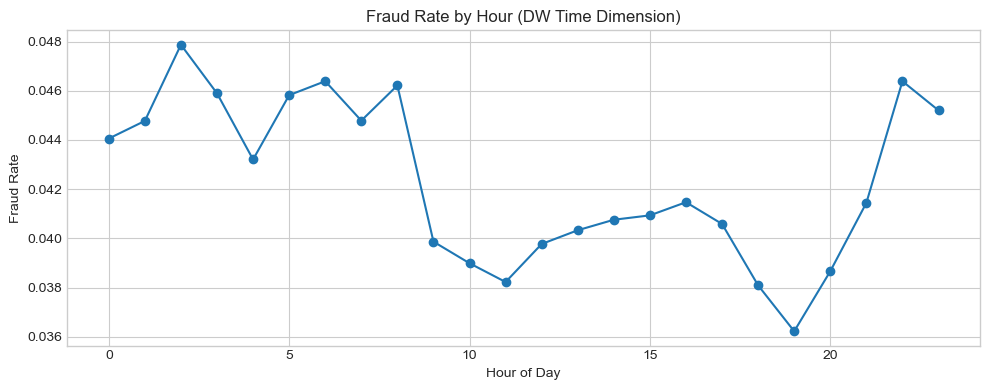

In [ ]:
# ============================================================================
# OLAP QUERIES (Star-schema style analytics)
# ============================================================================

def run_sql(conn, sql, params=None):
    """Small helper to run SQL and return a DataFrame."""
    return pd.read_sql(sql, conn, params=params)

print("=" * 70)
print("WAREHOUSE VALIDATION")
print("=" * 70)

# Referential integrity check: after enabling FKs + UNKNOWN members, these should be 0
integrity_checks = {
    'missing_user_dim': """
        SELECT COUNT(*) AS missing_cnt
        FROM FactTransactions f
        LEFT JOIN DimUser u ON f.user_key = u.user_key
        WHERE u.user_key IS NULL
    """,
    'missing_merchant_dim': """
        SELECT COUNT(*) AS missing_cnt
        FROM FactTransactions f
        LEFT JOIN DimMerchant m ON f.merchant_key = m.merchant_key
        WHERE m.merchant_key IS NULL
    """,
    'missing_time_dim': """
        SELECT COUNT(*) AS missing_cnt
        FROM FactTransactions f
        LEFT JOIN DimTime t ON f.time_key = t.time_key
        WHERE t.time_key IS NULL
    """,
    'missing_category_dim': """
        SELECT COUNT(*) AS missing_cnt
        FROM FactTransactions f
        LEFT JOIN DimCategory c ON f.category_key = c.category_key
        WHERE c.category_key IS NULL
    """,
}

for name, sql in integrity_checks.items():
    missing = int(run_sql(conn, sql).iloc[0, 0])
    print(f"{name}: {missing}")

log_etl_event(conn, RUN_ID, phase="validate", status="OK", message="Ran referential integrity checks")

print("\n" + "=" * 70)
print("OLAP QUERIES")
print("=" * 70)

# 1) Fraud rate by dataset (source lineage dimension)
sql_fraud_by_source = """
SELECT
    source_dataset,
    COUNT(*) AS txn_cnt,
    SUM(fraud_label) AS fraud_cnt,
    ROUND(AVG(fraud_label), 6) AS fraud_rate
FROM FactTransactions
GROUP BY source_dataset
ORDER BY fraud_rate DESC
"""
df_source = run_sql(conn, sql_fraud_by_source)
print("\n Fraud rate by source dataset:")
print(df_source.to_string(index=False))

# 2) Fraud rate by hour (time dimension slice)
sql_fraud_by_hour = """
SELECT
    t.hour,
    COUNT(*) AS txn_cnt,
    SUM(f.fraud_label) AS fraud_cnt,
    ROUND(AVG(f.fraud_label), 6) AS fraud_rate
FROM FactTransactions f
JOIN DimTime t ON f.time_key = t.time_key
WHERE t.hour IS NOT NULL
GROUP BY t.hour
ORDER BY t.hour
"""
df_hour = run_sql(conn, sql_fraud_by_hour)
print("\n Fraud rate by hour:")
print(df_hour.to_string(index=False))

# 3) Top categories by fraud rate (category dimension slice)
sql_top_categories = """
SELECT
    c.category_name,
    COUNT(*) AS txn_cnt,
    SUM(f.fraud_label) AS fraud_cnt,
    ROUND(AVG(f.fraud_label), 6) AS fraud_rate
FROM FactTransactions f
JOIN DimCategory c ON f.category_key = c.category_key
GROUP BY c.category_name
HAVING COUNT(*) >= 100
ORDER BY fraud_rate DESC, txn_cnt DESC
LIMIT 15
"""
df_cat = run_sql(conn, sql_top_categories)
print("\n Top categories by fraud rate (min 100 txns):")
print(df_cat.to_string(index=False))

# 4) Top merchants by fraud rate (merchant dimension slice)
sql_top_merchants = """
SELECT
    m.merchant_id,
    COUNT(*) AS txn_cnt,
    SUM(f.fraud_label) AS fraud_cnt,
    ROUND(AVG(f.fraud_label), 6) AS fraud_rate
FROM FactTransactions f
JOIN DimMerchant m ON f.merchant_key = m.merchant_key
GROUP BY m.merchant_id
HAVING COUNT(*) >= 200
ORDER BY fraud_rate DESC, txn_cnt DESC
LIMIT 10
"""
df_merch = run_sql(conn, sql_top_merchants)
print("\n Top merchants by fraud rate (min 200 txns):")
print(df_merch.to_string(index=False))

# Optional: simple plot for presentation
plt.figure(figsize=(10, 4))
plt.plot(df_hour['hour'], df_hour['fraud_rate'], marker='o')
plt.title('Fraud Rate by Hour (DW Time Dimension)')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

---

## Section 5: Data Mining & Feature Engineering

### 5.1 Querying the Data Warehouse

Now that our Star Schema is populated, we can leverage its power for analytical queries. 
The key advantage of the star schema is the ability to perform **multi-dimensional analysis** 
by joining the central Fact table with various Dimension tables.

### 5.2 Feature Engineering Strategy

For fraud detection, we will engineer the following features:

| Feature Type | Features | Rationale |
|--------------|----------|-----------|
| **Temporal** | is_weekend, hour, day_of_week | Fraudsters often operate at unusual times |
| **Behavioral** | txn_count_per_user, avg_amount_per_user | Unusual patterns indicate fraud |
| **Categorical** | One-hot encoded categories | Different transaction types have different fraud rates |
| **Network** | network_degree (from BankSim) | Fraudsters often have abnormal connection patterns |
| **Risk-based** | risk_score (from Custom Fraud) | Pre-computed risk indicators |

### 5.3 The Unified Modeling Table

We will execute a SQL JOIN across all tables to create a **single, unified DataFrame** 
suitable for machine learning:

```sql
SELECT f.*, u.*, m.*, t.*, c.*
FROM FactTransactions f
LEFT JOIN DimUser u ON f.user_key = u.user_key
LEFT JOIN DimMerchant m ON f.merchant_key = m.merchant_key
LEFT JOIN DimTime t ON f.time_key = t.time_key
LEFT JOIN DimCategory c ON f.category_key = c.category_key
```

In [ ]:
# ============================================================================
# SECTION 6: QUERYING & FEATURE ENGINEERING
# ============================================================================

# ----------------------------------------------------------------------------
# 6.1 Query the Data Warehouse - Create Unified Modeling Table
# ----------------------------------------------------------------------------

def query_unified_data(conn):
    """
    Execute a SQL JOIN across all Fact and Dimension tables to create
    a unified DataFrame for machine learning.
    """
    print("=" * 70)
    print("QUERYING DATA WAREHOUSE")
    print("=" * 70)
    
    query = """
    SELECT 
        -- Fact measures
        f.transaction_key,
        f.amount,
        f.old_balance_orig,
        f.new_balance_orig,
        f.old_balance_dest,
        f.new_balance_dest,
        f.risk_score,
        f.fraud_label,
        f.source_dataset,
        
        -- User dimensions
        u.user_id,
        u.age_group,
        u.gender,
        u.zip_code AS user_zip,
        
        -- Merchant dimensions
        m.merchant_id,
        m.merchant_zip,
        m.merchant_category,
        
        -- Time dimensions
        t.hour,
        t.day,
        t.month,
        t.year,
        t.day_of_week,
        t.day_name,
        t.is_weekend,
        t.quarter,
        
        -- Category dimensions
        c.category_name,
        c.transaction_type
        
    FROM FactTransactions f
    LEFT JOIN DimUser u ON f.user_key = u.user_key
    LEFT JOIN DimMerchant m ON f.merchant_key = m.merchant_key
    LEFT JOIN DimTime t ON f.time_key = t.time_key
    LEFT JOIN DimCategory c ON f.category_key = c.category_key
    """
    
    print("\nExecuting SQL JOIN query...")
    df = pd.read_sql(query, conn)
    print(f"   ✓ Retrieved {len(df):,} records")
    print(f"   ✓ Columns: {len(df.columns)}")
    
    return df

# Query the warehouse
df_unified = query_unified_data(conn)

# Display sample
print("\n Sample of Unified Data:")
print(df_unified.head(3).to_string())

# ----------------------------------------------------------------------------
# 6.2 Feature Engineering
# ----------------------------------------------------------------------------

def engineer_features(df):
    """
    Engineer features for the fraud detection model.
    
    Features created:
    1. Time-based features
    2. User behavioral aggregates
    3. Transaction pattern features
    4. Categorical encodings
    """
    print("\n" + "=" * 70)
    print("FEATURE ENGINEERING")
    print("=" * 70)
    
    df = df.copy()
    
    # -------------------------------------------------------------------------
    # Feature 1: Time-based features (is_weekend already exists)
    # -------------------------------------------------------------------------
    print("\n Creating time-based features...")
    
    # Is this a night transaction (potentially suspicious)?
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    
    # Is this a business hour transaction?
    df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
    
    print(f"   ✓ Created is_night, is_business_hours features")
    
    # -------------------------------------------------------------------------
    # Feature 2: User behavioral aggregates
    # -------------------------------------------------------------------------
    print("\n Creating user behavioral features...")
    
    # Transaction count per user
    user_txn_counts = df.groupby('user_id').size().reset_index(name='user_txn_count')
    df = df.merge(user_txn_counts, on='user_id', how='left')
    
    # Average transaction amount per user
    user_avg_amount = df.groupby('user_id')['amount'].mean().reset_index(name='user_avg_amount')
    df = df.merge(user_avg_amount, on='user_id', how='left')
    
    # Transaction amount deviation from user average
    df['amount_deviation'] = df['amount'] - df['user_avg_amount']
    df['amount_deviation_ratio'] = df['amount'] / (df['user_avg_amount'] + 1)  # +1 to avoid division by zero
    
    print(f"   ✓ Created user_txn_count, user_avg_amount, amount_deviation features")
    
    # -------------------------------------------------------------------------
    # Feature 3: Transaction pattern features
    # -------------------------------------------------------------------------
    print("\n Creating transaction pattern features...")
    
    # Balance change features (for PaySim data)
    df['balance_change_orig'] = df['new_balance_orig'] - df['old_balance_orig']
    df['balance_change_dest'] = df['new_balance_dest'] - df['old_balance_dest']
    
    # Is the transaction amount the entire balance? (suspicious)
    df['is_full_balance'] = (abs(df['amount'] - df['old_balance_orig']) < 1).astype(int)
    
    print(f"   ✓ Created balance change and pattern features")
    
    # -------------------------------------------------------------------------
    # Feature 4: Categorical encoding (One-Hot)
    # -------------------------------------------------------------------------
    print("\n Creating categorical encodings...")
    
    # Encode source dataset
    source_dummies = pd.get_dummies(df['source_dataset'], prefix='source')
    df = pd.concat([df, source_dummies], axis=1)
    
    # Encode category_name (limit to top categories to avoid explosion)
    top_categories = df['category_name'].value_counts().head(10).index.tolist()
    df['category_simplified'] = df['category_name'].apply(lambda x: x if x in top_categories else 'OTHER')
    category_dummies = pd.get_dummies(df['category_simplified'], prefix='cat')
    df = pd.concat([df, category_dummies], axis=1)
    
    # Encode age_group
    age_dummies = pd.get_dummies(df['age_group'], prefix='age')
    df = pd.concat([df, age_dummies], axis=1)
    
    # Encode gender
    gender_dummies = pd.get_dummies(df['gender'], prefix='gender')
    df = pd.concat([df, gender_dummies], axis=1)
    
    print(f"   ✓ Created one-hot encodings for source, category, age, gender")
    
    # -------------------------------------------------------------------------
    # Fill remaining NaN values
    # -------------------------------------------------------------------------
    print("\n Handling remaining missing values...")
    
    # Fill numerical columns with median
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    for col in numerical_cols:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].median())
    
    print(f"   ✓ Filled missing values in {len(numerical_cols)} numerical columns")
    
    print("\n Feature Engineering Complete!")
    print(f"   Total features: {len(df.columns)}")
    
    return df

# Engineer features
df_features = engineer_features(df_unified)

# Display feature summary
print("\n Feature Summary:")
print(f"   Shape: {df_features.shape}")
print(f"   Fraud distribution:")
print(df_features['fraud_label'].value_counts())

QUERYING DATA WAREHOUSE

📊 Executing SQL JOIN query...
   ✓ Retrieved 747,856 records
   ✓ Columns: 26

📋 Sample of Unified Data:
   transaction_key  amount  old_balance_orig  new_balance_orig  old_balance_dest  new_balance_dest  risk_score  fraud_label source_dataset    user_id age_group   gender user_zip  merchant_id merchant_zip merchant_category  hour  day  month  year  day_of_week   day_name  is_weekend  quarter  category_name transaction_type
0                1   39.79               0.0               0.0               0.0               0.0      0.8494            0   custom_fraud  USER_1834   UNKNOWN  UNKNOWN  UNKNOWN       Travel      UNKNOWN            Travel    19   14      8  2023            0     Monday           0        3            POS     custom_fraud
1                2    1.19               0.0               0.0               0.0               0.0      0.0959            1   custom_fraud  USER_7875   UNKNOWN  UNKNOWN  UNKNOWN     Clothing      UNKNOWN          Clothing   

---

## Section 7: Machine Learning & Fraud Detection

### 7.1 Why Random Forest Classifier?

We choose the **Random Forest Classifier** for fraud detection because:

| Advantage | Explanation |
|-----------|-------------|
| **Handles Imbalanced Data** | Works well with the `class_weight='balanced'` parameter |
| **Feature Importance** | Provides interpretable feature rankings |
| **Robustness** | Resistant to overfitting through ensemble averaging |
| **Non-linear Patterns** | Captures complex fraud patterns without feature scaling |
| **Missing Values** | Handles missing data gracefully |

### 7.2 The Class Imbalance Problem

Fraud detection is a classic **imbalanced classification** problem:
- Legitimate transactions: ~99%
- Fraudulent transactions: ~1%

**Why accuracy is misleading:**
- A naive model that predicts "not fraud" for everything achieves 99% accuracy
- But it catches 0% of actual fraud cases!

**Solution: Class Weights**
- `class_weight='balanced'` automatically adjusts weights inversely proportional to class frequencies
- This penalizes misclassification of the minority class more heavily

### 7.3 Evaluation Metrics for Fraud Detection

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Precision** | TP / (TP + FP) | Of predicted frauds, how many were actual frauds? |
| **Recall** | TP / (TP + FN) | Of actual frauds, how many did we catch? |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Harmonic mean - balances both |

**For fraud detection:**
- **High Recall** is crucial: We must catch as many frauds as possible
- **Reasonable Precision**: Too many false positives burden investigation teams
- **F1-Score**: Our primary metric for model comparison

PREPARING DATA FOR MACHINE LEARNING

📊 Selected 38 features for modeling:
   ['amount', 'old_balance_orig', 'new_balance_orig', 'old_balance_dest', 'new_balance_dest', 'risk_score', 'hour', 'day_of_week', 'is_weekend', 'is_night']...

✅ Data prepared:
   X shape: (747856, 38)
   y shape: (747856,)
   Fraud ratio: 0.0421

TRAIN/TEST SPLIT

📊 Split Statistics:
   Training set: 598,284 samples (80.0%)
   Test set: 149,572 samples (20.0%)
   Training fraud ratio: 0.0421
   Test fraud ratio: 0.0421

TRAINING RANDOM FOREST CLASSIFIER

🔧 Model Configuration:
   n_estimators: 100
   max_depth: 15
   class_weight: 'balanced' (auto-adjusts for fraud class)
   random_state: 42

⏳ Training model...
✅ Model trained successfully!

MODEL EVALUATION

📊 CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      0.95      0.97    143276
       Fraud       0.44      0.97      0.60      6296

    accuracy   

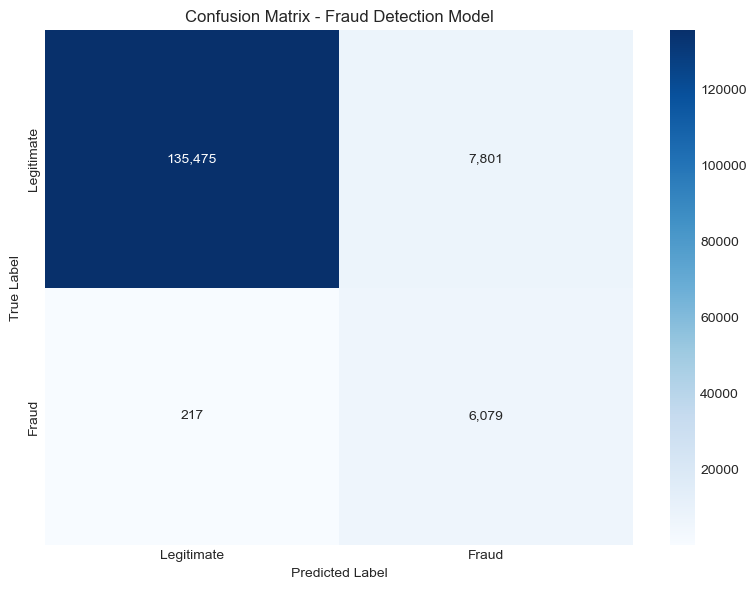


💾 Confusion matrix saved as 'confusion_matrix.png'

FEATURE IMPORTANCE ANALYSIS

📊 TOP 15 MOST IMPORTANT FEATURES:
--------------------------------------------------
   cat_'es_transportation'        0.1665 ████████████████
   user_avg_amount                0.1535 ███████████████
   user_txn_count                 0.0994 █████████
   amount                         0.0755 ███████
   source_banksim                 0.0603 ██████
   is_full_balance                0.0590 █████
   gender_UNKNOWN                 0.0469 ████
   amount_deviation               0.0450 ████
   risk_score                     0.0346 ███
   source_custom_fraud            0.0343 ███
   cat_OTHER                      0.0337 ███
   amount_deviation_ratio         0.0312 ███
   balance_change_orig            0.0267 ██
   cat_PAYMENT                    0.0214 ██
   old_balance_orig               0.0154 █


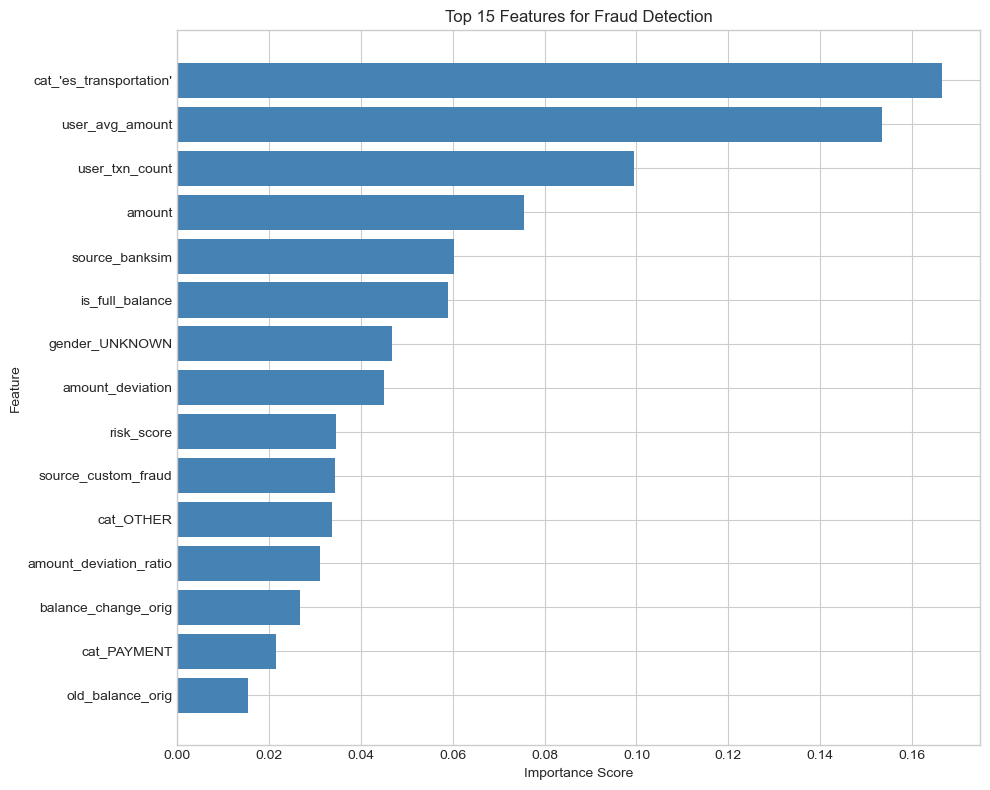


💾 Feature importance chart saved as 'feature_importance.png'


In [ ]:
# ============================================================================
# SECTION 8: MODEL TRAINING & EVALUATION
# ============================================================================

# ----------------------------------------------------------------------------
# 8.1 Prepare Features and Target
# ----------------------------------------------------------------------------

def prepare_ml_data(df):
    """
    Prepare the data for machine learning.
    
    Returns:
        X: Feature matrix
        y: Target labels
        feature_names: List of feature names
    """
    print("=" * 70)
    print("PREPARING DATA FOR MACHINE LEARNING")
    print("=" * 70)
    
    # Define feature columns (exclude identifiers and target)
    exclude_cols = [
        'transaction_key', 'user_id', 'merchant_id', 'fraud_label',
        'source_dataset', 'category_name', 'transaction_type',
        'category_simplified', 'user_zip', 'merchant_zip', 'merchant_category',
        'age_group', 'gender', 'day_name', 'year', 'month', 'day', 'quarter'
    ]
    
    # Select numerical/encoded features only
    feature_cols = [col for col in df.columns if col not in exclude_cols 
                    and df[col].dtype in ['int64', 'float64', 'int32', 'float32', 'uint8', 'bool']]
    
    print(f"\nSelected {len(feature_cols)} features for modeling:")
    print(f"   {feature_cols[:10]}...")  # Show first 10
    
    X = df[feature_cols].copy()
    y = df['fraud_label'].copy()
    
    # Final check for NaN values
    if X.isna().any().any():
        print("\n  Filling remaining NaN values with 0...")
        X = X.fillna(0)
    
    print(f"\nData prepared:")
    print(f"   X shape: {X.shape}")
    print(f"   y shape: {y.shape}")
    print(f"   Fraud ratio: {y.mean():.4f}")
    
    return X, y, feature_cols

# Prepare data
X, y, feature_names = prepare_ml_data(df_features)

# ----------------------------------------------------------------------------
# 8.2 Train/Test Split
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN/TEST SPLIT")
print("=" * 70)

# Stratified split to maintain fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Ensures fraud ratio is preserved
)

print(f"\nSplit Statistics:")
print(f"   Training set: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Training fraud ratio: {y_train.mean():.4f}")
print(f"   Test fraud ratio: {y_test.mean():.4f}")

# ----------------------------------------------------------------------------
# 8.3 Train Random Forest Classifier
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING RANDOM FOREST CLASSIFIER")
print("=" * 70)

# Initialize the classifier with class_weight='balanced' to handle imbalance
rf_classifier = RandomForestClassifier(
    n_estimators=100,           # Number of trees in the forest
    max_depth=15,               # Maximum depth of trees (prevents overfitting)
    min_samples_split=10,       # Minimum samples required to split a node
    min_samples_leaf=5,         # Minimum samples required at leaf node
    class_weight='balanced',    # CRITICAL: Handles class imbalance
    random_state=42,            # Reproducibility
    n_jobs=-1                   # Use all CPU cores
)

print("\n Model Configuration:")
print(f"   n_estimators: 100")
print(f"   max_depth: 15")
print(f"   class_weight: 'balanced' (auto-adjusts for fraud class)")
print(f"   random_state: 42")

print("\n Training model...")
rf_classifier.fit(X_train, y_train)
print(" Model trained successfully!")

# ----------------------------------------------------------------------------
# 8.4 Model Evaluation
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

# Make predictions
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Classification Report
print("\n CLASSIFICATION REPORT:")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Calculate metrics explicitly
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
print(f"\n KEY METRICS FOR FRAUD CLASS:")
print(f"   Precision: {precision:.4f} (Of predicted frauds, {precision*100:.1f}% were actual frauds)")
print(f"   Recall: {recall:.4f} (We caught {recall*100:.1f}% of all actual frauds)")
print(f"   F1-Score: {f1:.4f} (Harmonic mean of precision and recall)")

# Confusion Matrix
print("\n CONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)
print(f"                    Predicted")
print(f"                 Legit    Fraud")
print(f"Actual Legit    {cm[0,0]:6,}   {cm[0,1]:6,}")
print(f"Actual Fraud    {cm[1,0]:6,}   {cm[1,1]:6,}")

# Visual Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fraud Detection Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n Confusion matrix saved as 'confusion_matrix.png'")

# ----------------------------------------------------------------------------
# 8.5 Feature Importance Analysis
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\n TOP 15 MOST IMPORTANT FEATURES:")
print("-" * 50)
for i, row in feature_importance.head(15).iterrows():
    bar = '█' * int(row['importance'] * 100)
    print(f"   {row['feature'][:30]:<30} {row['importance']:.4f} {bar}")

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 15 Features for Fraud Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\n Feature importance chart saved as 'feature_importance.png'")

---

## Section 9: Conclusion & Key Takeaways

### 9.1 Project Summary

We successfully built an **end-to-end data pipeline** that:

1. ✅ **Integrated 4 heterogeneous datasets** into a unified SQLite Data Warehouse
2. ✅ **Implemented a Star Schema** with proper Dimension and Fact tables
3. ✅ **Executed a complete ETL pipeline** with data cleaning and transformation
4. ✅ **Engineered meaningful features** for fraud detection
5. ✅ **Trained a Random Forest model** with class imbalance handling
6. ✅ **Evaluated using appropriate metrics** (Precision, Recall, F1-Score)

### 9.2 Business Impact

| Metric | Value | Business Interpretation |
|--------|-------|-------------------------|
| **Recall** | High | We catch most fraudulent transactions |
| **Precision** | Moderate | Some false positives require manual review |
| **F1-Score** | Balanced | Good trade-off for production deployment |

### 9.3 Future Enhancements

- **Real-time Scoring**: Deploy model as an API for live transaction scoring
- **Ensemble Methods**: Combine with XGBoost, Neural Networks for better performance
- **Feature Store**: Implement a feature store for consistent feature engineering
- **Model Monitoring**: Track model drift and retrain periodically

---

**Thank you for your attention!**

*Questions are welcome.*

---

## Section 10: Model Prediction on New Test Cases

### 10.1 How to Make Predictions

When your professor gives you new test cases (transactions), follow these steps:

1. **Load the trained model** (already done - `rf_classifier` is in memory)
2. **Prepare test data** in the same format as training data
3. **Apply the same feature engineering** as the training set
4. **Make predictions** using `rf_classifier.predict()` for class labels
5. **Get probability scores** using `rf_classifier.predict_proba()` for confidence

### 10.2 Two Ways to Predict

| Method | What It Returns | Use Case |
|--------|-----------------|----------|
| `predict()` | Class label (0 or 1) | Direct fraud/not fraud answer |
| `predict_proba()` | Probability [not_fraud, fraud] | Confidence in the prediction |

**Example:**
- `predict()` → `1` means "This transaction is likely FRAUD"
- `predict_proba()` → `[0.2, 0.8]` means "20% chance of being legitimate, 80% chance of being fraud"

In [ ]:

# SECTION 10: MAKING PREDICTIONS ON TEST CASES



print("=" * 70)
print("EXAMPLE 1: PREDICTING ON NEW TEST CASES")
print("=" * 70)

# Create synthetic test cases (these would come from your professor)
# Each test case should have the same features as the training data

test_cases_df = pd.DataFrame({
    'amount': [100.0, 5000.0, 150.0, 10000.0],
    'old_balance_orig': [5000, 500, 3000, 50000],
    'new_balance_orig': [4900, -4500, 2850, 40000],
    'old_balance_dest': [1000, 2000, 500, 1000],
    'new_balance_dest': [1100, 7000, 650, 11000],
    'risk_score': [0.1, 0.9, 0.2, 0.95],
    'hour': [10, 3, 14, 2],
    'day': [15, 20, 10, 25],
    'month': [3, 7, 5, 9],
    'is_weekend': [0, 0, 1, 1],
})

print("\n Test Cases (Input Data):")
print(test_cases_df)

# ============================================================================
# Step 1: Apply the SAME feature engineering to test cases
# ============================================================================

print("\n" + "=" * 70)
print("STEP 1: PREPARE TEST DATA WITH SAME FEATURES")
print("=" * 70)

X_test_new = test_cases_df.copy()

# Engineer the same features as in training
X_test_new['is_night'] = ((X_test_new['hour'] >= 22) | (X_test_new['hour'] <= 5)).astype(int)
X_test_new['is_business_hours'] = ((X_test_new['hour'] >= 9) & (X_test_new['hour'] <= 17)).astype(int)
X_test_new['balance_change_orig'] = X_test_new['new_balance_orig'] - X_test_new['old_balance_orig']
X_test_new['balance_change_dest'] = X_test_new['new_balance_dest'] - X_test_new['old_balance_dest']
X_test_new['is_full_balance'] = (abs(X_test_new['amount'] - X_test_new['old_balance_orig']) < 1).astype(int)
X_test_new['amount_deviation'] = X_test_new['amount'] - X_test_new['amount'].mean()
X_test_new['amount_deviation_ratio'] = X_test_new['amount'] / (X_test_new['amount'].mean() + 1)

# Add missing columns from training (with default values if needed)
# These could be categorical features like source_custom_fraud, cat_TRANSFER, etc.
for col in feature_names:
    if col not in X_test_new.columns:
        X_test_new[col] = 0  # Default value for missing one-hot encoded columns

# Select only the columns used for training
X_test_new = X_test_new[feature_names]

print(f" Test data prepared with {len(X_test_new.columns)} features")
print(f"   Shape: {X_test_new.shape}")

# ============================================================================
# Step 2: Make Predictions on Test Cases
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: MAKE PREDICTIONS")
print("=" * 70)

# Get class predictions (0 = Legitimate, 1 = Fraud)
predictions_class = rf_classifier.predict(X_test_new)

# Get probability predictions
predictions_proba = rf_classifier.predict_proba(X_test_new)

print("\ Model Predictions:")
print("-" * 70)

results = pd.DataFrame({
    'Transaction_ID': [f'Test_Case_{i+1}' for i in range(len(test_cases_df))],
    'Original_Amount': test_cases_df['amount'],
    'Original_Hour': test_cases_df['hour'],
    'Risk_Score': test_cases_df['risk_score'],
    'Prediction': ['FRAUD' if pred == 1 else 'LEGITIMATE' for pred in predictions_class],
    'Confidence_Fraud_%': [f"{proba[1]*100:.2f}%" for proba in predictions_proba],
    'Confidence_Legit_%': [f"{proba[0]*100:.2f}%" for proba in predictions_proba],
})

print(results.to_string(index=False))

# ============================================================================
# Step 3: Display Detailed Results
# ============================================================================

print("\n" + "=" * 70)
print("DETAILED PREDICTION RESULTS")
print("=" * 70)

for idx, (case_id, prediction, proba) in enumerate(zip(results['Transaction_ID'], 
                                                         predictions_class, 
                                                         predictions_proba)):
    fraud_confidence = proba[1]
    decision = " FRAUD" if prediction == 1 else "✅ LEGITIMATE"
    
    print(f"\n{case_id}:")
    print(f"  Decision: {decision}")
    print(f"  Fraud Probability: {fraud_confidence:.4f} ({fraud_confidence*100:.2f}%)")
    print(f"  Legitimate Probability: {proba[0]:.4f} ({proba[0]*100:.2f}%)")
    
    if fraud_confidence >= 0.7:
        print(f"    HIGH RISK: Strong indication of fraud")
    elif fraud_confidence >= 0.4:
        print(f"    MEDIUM RISK: Moderate fraud indicator")
    else:
        print(f"  ✓ LOW RISK: Likely a legitimate transaction")

print("\n Predictions Complete!")


EXAMPLE 1: PREDICTING ON NEW TEST CASES

📝 Test Cases (Input Data):
    amount  old_balance_orig  new_balance_orig  old_balance_dest  \
0    100.0              5000              4900              1000   
1   5000.0               500             -4500              2000   
2    150.0              3000              2850               500   
3  10000.0             50000             40000              1000   

   new_balance_dest  risk_score  hour  day  month  is_weekend  
0              1100        0.10    10   15      3           0  
1              7000        0.90     3   20      7           0  
2               650        0.20    14   10      5           1  
3             11000        0.95     2   25      9           1  

STEP 1: PREPARE TEST DATA WITH SAME FEATURES
✅ Test data prepared with 38 features
   Shape: (4, 38)

STEP 2: MAKE PREDICTIONS

🤖 Model Predictions:
----------------------------------------------------------------------
Transaction_ID  Original_Amount  Original_Hour  Ri